[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/soumyaroy799/SUIT_solar_workshops/blob/main/workshops/USO_Vikram_2026_Oct/notebooks/coalignment.ipynb)

### First we will set the environment, download the data necessary. You do not need to really care about this, the necessary important parts start from the cell after this.

In [1]:
import sys
import subprocess
import urllib.request
import zipfile
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules

REPO_URL = "https://github.com/soumyaroy799/SUIT_solar_workshops.git"

DATA_URL = (
    "https://www.dropbox.com/scl/fi/"
    "5sk2tw3vyyueuvznbwk1l/data.zip"
    "?rlkey=j6d7hrcnrdujj25u87ojc7r7i"
    "&dl=1"
)

# --------------------------------------------------
# Locate repository
# --------------------------------------------------

if IN_COLAB:

    print("Running in Google Colab")

    ROOT = Path("SUIT_solar_workshops")

    if not ROOT.exists():

        print("Cloning workshop repository...")

        subprocess.run(
            ["git", "clone", REPO_URL],
            check=True,
        )

    ROOT = ROOT.resolve()

else:

    print("Running locally")

    ROOT = Path.cwd().resolve()

    while ROOT.name != "SUIT_solar_workshops":

        if ROOT.parent == ROOT:

            raise RuntimeError(
                "Could not find SUIT_solar_workshops repository root.\n"
                "Please run this notebook from inside the cloned repository."
            )

        ROOT = ROOT.parent

print(f"Repository root: {ROOT}")

# --------------------------------------------------
# Install requirements (Colab only)
# --------------------------------------------------

if IN_COLAB:

    req_file = ROOT / "requirements.txt"

    if not req_file.exists():

        raise FileNotFoundError(
            f"Could not find requirements.txt at {req_file}"
        )

    print("Installing workshop requirements...")

    try:

        subprocess.run(
            [
                sys.executable,
                "-m",
                "pip",
                "install",
                "-q",
                "-r",
                str(req_file),
            ],
            check=True,
        )

        subprocess.run(
            [
                sys.executable,
                "-m",
                "pip",
                "install",
                "-q",
                "ipympl",
                "ipywidgets",
            ],
            check=True,
        )

        from google.colab import output

        output.enable_custom_widget_manager()

        print("Colab widget support enabled")

    except subprocess.CalledProcessError:

        print(
            "\nFailed to install requirements.txt\n"
        )

        with open(req_file) as f:
            print(f.read())

        raise

# --------------------------------------------------
# Workshop data
# --------------------------------------------------

WORKSHOP_DIR = ROOT / "workshops" / "USO_Vikram_2026_Oct"
DATA_DIR = WORKSHOP_DIR / "data"

REQUIRED_FILES = [
    DATA_DIR / "SUTNB01.fits",
    DATA_DIR / "ROI_SUT_NB01.fits",
]


def workshop_data_present():
    """Check whether required workshop files exist."""
    return all(f.exists() for f in REQUIRED_FILES)


def download_workshop_data():
    """Download and extract workshop data."""

    WORKSHOP_DIR.mkdir(parents=True, exist_ok=True)
    DATA_DIR.mkdir(parents=True, exist_ok=True)

    zip_path = WORKSHOP_DIR / "data.zip"

    print("Downloading workshop data...")

    try:
        urllib.request.urlretrieve(
            DATA_URL,
            zip_path,
        )
    except Exception as e:
        raise RuntimeError(
            f"Failed to download workshop data:\n{e}"
        )

    print("Extracting workshop data...")

    try:
        with zipfile.ZipFile(zip_path, "r") as zf:
            zf.extractall(DATA_DIR)
    except zipfile.BadZipFile:
        raise RuntimeError(
            "Downloaded file is not a valid ZIP archive. "
            "Check the Dropbox sharing link."
        )

    zip_path.unlink(missing_ok=True)

    fits_files = sorted(DATA_DIR.glob("*.fits"))

    print(
        f"Workshop data ready "
        f"({len(fits_files)} FITS files found)."
    )


if workshop_data_present():

    fits_files = sorted(DATA_DIR.glob("*.fits"))

    print(
        f"Workshop data already available "
        f"({len(fits_files)} FITS files found)."
    )

else:

    print("Workshop data missing or incomplete.")

    download_workshop_data()

    if not workshop_data_present():

        raise RuntimeError(
            "Workshop data download completed, but required FITS "
            "files were not found. Check the ZIP structure."
        )

Running locally
Repository root: /Users/soumyaroy/Documents/GitHub/SUIT_solar_workshops
Workshop data already available (19 FITS files found).


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
from glob import glob
from sunpy.map import Map
from datetime import datetime
import astropy.units as u
from astropy.coordinates import SkyCoord
import matplotlib.patches as patches

from sunkit_image.coalignment import (
    calculate_match_template_shift as cal_shift
)
from sunkit_image.coalignment import apply_shifts

from sunpy.coordinates import get_horizons_coord
from sunpy.map import get_observer_meta

import warnings
warnings.filterwarnings("ignore")

from copy import deepcopy

In [3]:
def co_align(map_sequence, template, layer_index=0, clip=False):
    """
    Co-align a map sequence to a template.

    Parameters
    ----------
    map_sequence : sequence of sunpy.map.Map
    template : sunpy.map.Map
        Template used for cross-correlation.
    layer_index : int, optional
        Reference layer in the sequence.
    clip : bool, optional
        Clip edge pixels affected by shifting.

    Returns
    -------
    list
        Co-aligned maps.
    """

    shifts = cal_shift(
        map_sequence,
        layer_index=layer_index,
        template=template
    )

    plate_scale = map_sequence[0].scale[0]

    return apply_shifts(
        map_sequence,
        xshift=-shifts["x"] / plate_scale,
        yshift=-shifts["y"] / plate_scale,
        clip=clip,
    )

def submap_with_ginput(sunpy_map):
    """
    Interactively select a rectangular ROI and return a submap.

    Parameters
    ----------
    sunpy_map : sunpy.map.Map

    Returns
    -------
    submap : sunpy.map.Map
    """

    fig = plt.figure(figsize=(8, 8))
    ax = fig.add_subplot(projection=sunpy_map)

    sunpy_map.plot(axes=ax)

    ax.set_title(
        "Click bottom-left and top-right corners"
    )

    plt.show(block=False)

    pts = plt.ginput(n=2,timeout=-1,show_clicks=True)

    if len(pts) != 2:

        plt.close(fig)

        raise RuntimeError("ROI selection cancelled.")

    (x1, y1), (x2, y2) = pts

    xmin = min(x1, x2)
    xmax = max(x1, x2)

    ymin = min(y1, y2)
    ymax = max(y1, y2)

    rect = patches.Rectangle((xmin, ymin), xmax - xmin, ymax - ymin, fill=False, linewidth=2,)

    ax.add_patch(rect)

    fig.canvas.draw()

    bottom_left = u.Quantity([xmin, ymin], u.pixel)

    top_right = u.Quantity([xmax, ymax], u.pixel)

    submap = sunpy_map.submap(bottom_left=bottom_left, top_right=top_right,)

    plt.close(fig)

    return submap

## Loading SUIT Images

### In this section, we load a sequence of SUIT Region-of-Interest (RoI) images and create a SunPy `MapSequence`. We will use these images to demonstrate image coalignment techniques.

#### SUIT (Solar Ultraviolet Imaging Telescope) is one of the remote-sensing payloads onboard Aditya-L1. It observes the Sun in 11 ultraviolet passbands (8 narrow-band and 3 broad-band filters) covering the wavelength range 200–400 nm. SUIT provides both full-disk and Region-of-Interest observations, allowing high-cadence studies of solar activity in selected regions. :chatgpt-content-reference{index="0"}

#### The example data for this workshop are provided in:

```text
workshops/USO_Vikram_2026_Oct/data/
```

#### The following cell loads all FITS files in this directory into a SunPy `MapSequence`.


### For a detailed description of SUIT, its observing modes, filters, and science objectives, see [Tripathi et al. (2025)](https://link.springer.com/article/10.1007/s11207-025-02423-1)

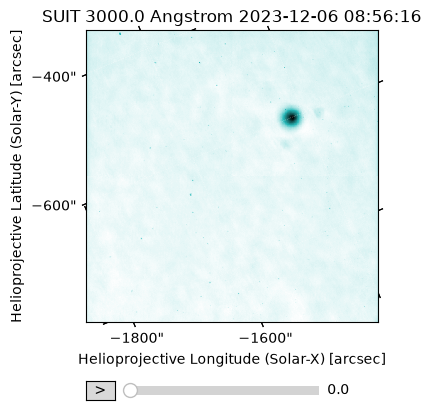

In [4]:
files = sorted(DATA_DIR.glob("*.fits"))

smaps = Map([str(f) for f in files], sequence=True)

smaps.peek()

In [5]:
plt.close()

 ## Making a template to colaign the maps.
 Cautions while making a template;
   1. Pick a region which does not change and appears similar in all the images in your map sequence
   2. Always pick a region which is smaller than the size of the map.
   3. Sunspots are a good choice if you are trying to coalign different filters as they will appear in all filters with fairly similar structure.

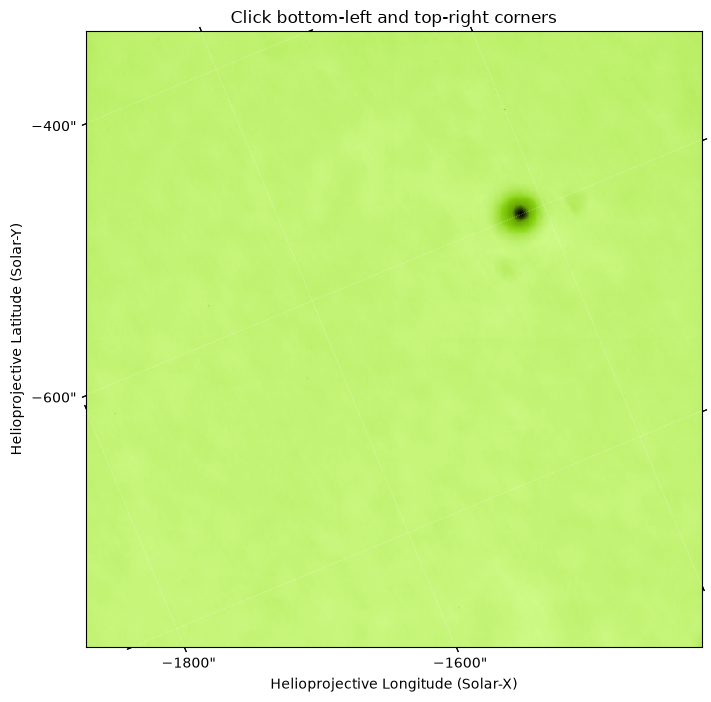

In [ ]:
index_nb3 = 1
template = submap_with_ginput(smaps[index_nb3])
plt.figure()
template.plot()

# run this cell again if you want to change your template.

In [7]:
plt.close()

# from mpl_animators.base import BaseFuncAnimator

# def _dehighlight_slider(self, ind):

#     ax = self.sliders[ind]

#     [a.set_linewidth(1.0)
#      for n, a in ax.spines.items()]

#     self.fig.canvas.draw_idle()

# def _highlight_slider(self, ind):

#     ax = self.sliders[ind]

#     [a.set_linewidth(2.0)
#      for n, a in ax.spines.items()]

#     self.fig.canvas.draw_idle()

# BaseFuncAnimator._dehighlight_slider = (
#     _dehighlight_slider
# )

# BaseFuncAnimator._highlight_slider = (
#     _highlight_slider
# )

In [6]:
coaligned_maps = co_align(smaps,template=template,layer_index=index_nb3)
# coaligned_maps.peek()

# if the maps are not coaligned properly, go back to the previous cell and select a new template.
# Have Fun

In [9]:
from mpl_animators.base import BaseFuncAnimator

def _dehighlight_slider(self, ind):
    ax = self.sliders[ind]
    [a.set_linewidth(1.0) for n, a in ax.spines.items()]
    self.fig.canvas.draw_idle()

def _highlight_slider(self, ind):
    ax = self.sliders[ind]
    [a.set_linewidth(2.0) for n, a in ax.spines.items()]
    self.fig.canvas.draw_idle()

BaseFuncAnimator._dehighlight_slider = _dehighlight_slider
BaseFuncAnimator._highlight_slider = _highlight_slider

In [10]:
smaps.peek()